# Exploratory Analysis

## Import Libraries

In [1]:
# Import necessary libraries for data analysis and visualization
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Read and Clean Data

In [ ]:
# Read data from CSV files
df_rock = pd.read_csv('data/rock.csv')
df_alternative = pd.read_csv('data/alternative.csv')
df_pop = pd.read_csv('data/pop.csv')
df_rap_rb = pd.read_csv('data/rap-r&b.csv')

# Add playlist column to each dataset
df_rock['Playlist'] = 'Rock'
df_alternative['Playlist'] = 'Alternative'
df_pop['Playlist'] = 'Pop'
df_rap_rb['Playlist'] = 'Rap-R&B'

# Create one combined dataframe for all playlists
df_library = pd.concat([df_rock, df_alternative, df_pop, df_rap_rb], ignore_index=True)

# Add album year from 'Album Date' column and create a new column 'album_year' as year
df_library['album_year'] = pd.to_datetime(df_library['Album Date'], errors='coerce').dt.year
df_library

,#,Song,Artist,BPM,Camelot,Energy,Added At,Duration,Popularity,Genres,...,Valence,Speech,Live,Loud (Db),Key,Time Signature,Spotify Track Id,ISRC,Playlist,album_year
0,1,When the Love is Gone,Des Rocs,141,9A,81,2026-03-05,03:20,52,NaN,...,47,0,20,-4,E Minor,4,5iRv1aH4eNai45KfhjtJ6n,USFYZ2557602,Rock,2026.0
1,2,BURNER PHONE,cleopatrick,136,9A,91,2026-03-05,03:21,42,NaN,...,46,0,30,-5,E Minor,4,1nUC2uuKUl49tDwQ1m4A1J,CAJXF2500023,Rock,2025.0
2,3,Queen Of Spades,Styx,135,12A,45,2026-03-05,05:41,36,"classic rock, aor, progressive rock",...,12,0,10,-13,C♯/D♭ Minor,4,54g63GAn77x9NcjiLzy7cW,USAM17802305,Rock,1978.0
3,4,Go Your Own Way,Fleetwood Mac,136,7B,81,2026-03-05,03:38,62,"yacht rock, classic rock, soft rock",...,82,0,10,-12,F Major,4,15rjQH7nTcTomKwfVMd4xl,USWB19900181,Rock,1988.0
4,5,I Don't Care Anymore - 2016 Remaster,Phil Collins,140,1B,42,2026-03-05,05:05,61,soft rock,...,44,0,0,-8,B Major,4,24IdPCimVnJJDRuB5YSDiS,USRH11509311,Rock,1982.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,246,Not Like Us,Kendrick Lamar,101,3B,47,2026-03-10,04:34,88,"hip hop, west coast hip hop",...,21,0,10,-7,C♯/D♭ Major,4,6AI3ezQ4o3HUoP6Dhudph3,USUG12400910,Rap-R&B,2024.0
996,247,THANK GODDESS,Qveen Herby,106,8A,74,2026-03-11,02:47,52,NaN,...,38,10,0,-5,A Minor,4,27IubiEgQJczAE6OC7PgmQ,QZFZ62344251,Rap-R&B,2023.0
997,248,STUPID (feat. Yung Baby Tate),"Ashnikko,Baby Tate",150,10B,64,2026-03-11,02:47,65,NaN,...,54,10,0,-7,D Major,4,6qNB2ChCVPepl5ZjVJJTUW,GBAYE1900593,Rap-R&B,2019.0
998,249,HAHAHA,Lil Dicky,158,3B,49,2026-03-11,04:03,41,NaN,...,14,10,10,-7,C♯/D♭ Major,4,73cnzXHK8i4WC5Pw0ZIZ2F,QMRSZ2302742,Rap-R&B,2024.0


## Explore Data

Exploring the library across three dimensions: artist representation (how many songs per artist, 
distribution across playlists), popularity (Spotify popularity scores), and album year (songs and albumns by decade).

### Songs by Artists

In [ ]:
# Count the number of songs by each artist in the library
df_artists = df_library['Artist'].value_counts().reset_index()
df_artists.columns = ['Artist', 'Count']

# Group by playlist and artist to count the number of songs by each artist in each playlist
df_artists_by_playlist = df_library.groupby(['Playlist', 'Artist']).size().reset_index(name='Count')

# Count the number of unique artists in each playlist
unique_artists_by_playlist = df_library.groupby('Playlist')['Artist'].nunique().reset_index(name='Unique Artists')

# Print number of artists
print(f"Number of unique artists in the library: {len(df_artists)}")

# Print number of unique artists by playlist
print("\nNumber of unique artists by playlist:")
for index, row in unique_artists_by_playlist.iterrows():
    print(f"  {row['Playlist']}: {row['Unique Artists']}") 

Number of unique artists in the library: 586

Number of unique artists by playlist:
  Alternative: 152
  Pop: 141
  Rap-R&B: 182
  Rock: 144


In [23]:
# Get number of songs by each artist
df_artists

,Artist,Count
0,Rainbow Kitten Surprise,10
1,Backstreet Boys,10
2,Eminem,10
3,Foreign Air,9
4,Matt Maeson,9
...,...,...
581,Tommy Richman,1
582,Qveen Herby,1
583,"Ashnikko,Baby Tate",1
584,Lil Dicky,1


In [31]:
# Get number of songs by each artist for each playlist
df_artists_by_playlist

,Playlist,Artist,Count
0,Alternative,1ST VOWS,1
1,Alternative,AWOLNATION,3
2,Alternative,"Absofacto,Herizen",1
3,Alternative,"Absofacto,NITESHIFT",1
4,Alternative,Alabama Shakes,1
...,...,...,...
614,Rock,Wheatus,1
615,Rock,Yeah Yeah Yeahs,4
616,Rock,blink-182,1
617,Rock,cleopatrick,6


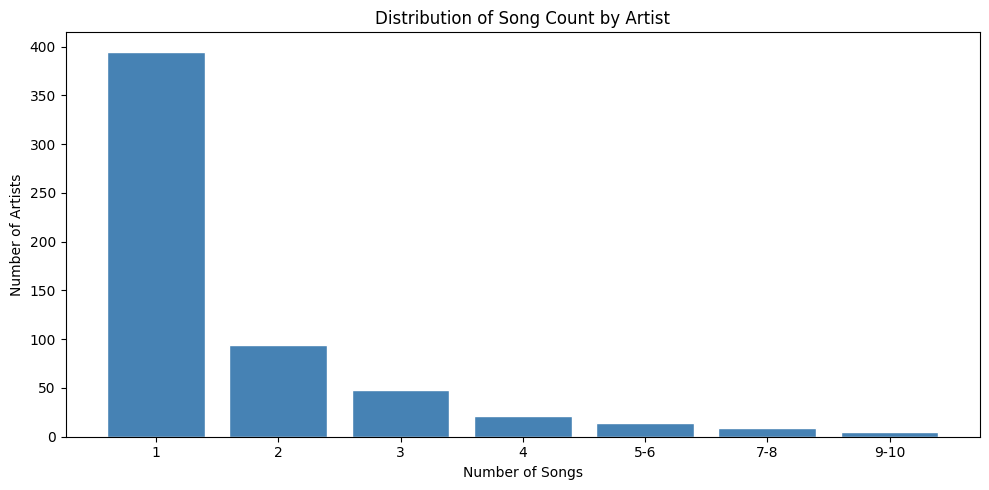

In [40]:
# Bin counts: 1-4 stay individual, 5-6, 7-8, 9-10 merged
def bin_count(x):
    if x <= 4:
        return str(x)
    elif x <= 6:
        return '5-6'
    elif x <= 8:
        return '7-8'
    elif x <= 10:
        return '9-10'
    else:
        return '11+'

df_artists['Bin'] = df_artists['Count'].apply(bin_count)

bin_order = ['1', '2', '3', '4', '5-6', '7-8', '9-10']
freq = df_artists['Bin'].value_counts().reindex(bin_order, fill_value=0)

plt.figure(figsize=(10, 5))
plt.bar(freq.index, freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Number of Songs')
plt.ylabel('Number of Artists')
plt.title('Distribution of Song Count by Artist')
plt.tight_layout()
plt.show()

In [41]:
# Plot for each playlist
def plot_artist_distribution(playlist):
    df_playlist = df_artists_by_playlist[df_artists_by_playlist['Playlist'] == playlist]
    df_playlist['Bin'] = df_playlist['Count'].apply(bin_count)
    freq = df_playlist['Bin'].value_counts().reindex(bin_order, fill_value=0)
    
    plt.figure(figsize=(10, 5))
    plt.bar(freq.index, freq.values, color='steelblue', edgecolor='white')
    plt.xlabel('Number of Songs')
    plt.ylabel('Number of Artists')
    plt.title(f'Distribution of Song Count by Artist in {playlist} Playlist')
    plt.tight_layout()
    plt.show()


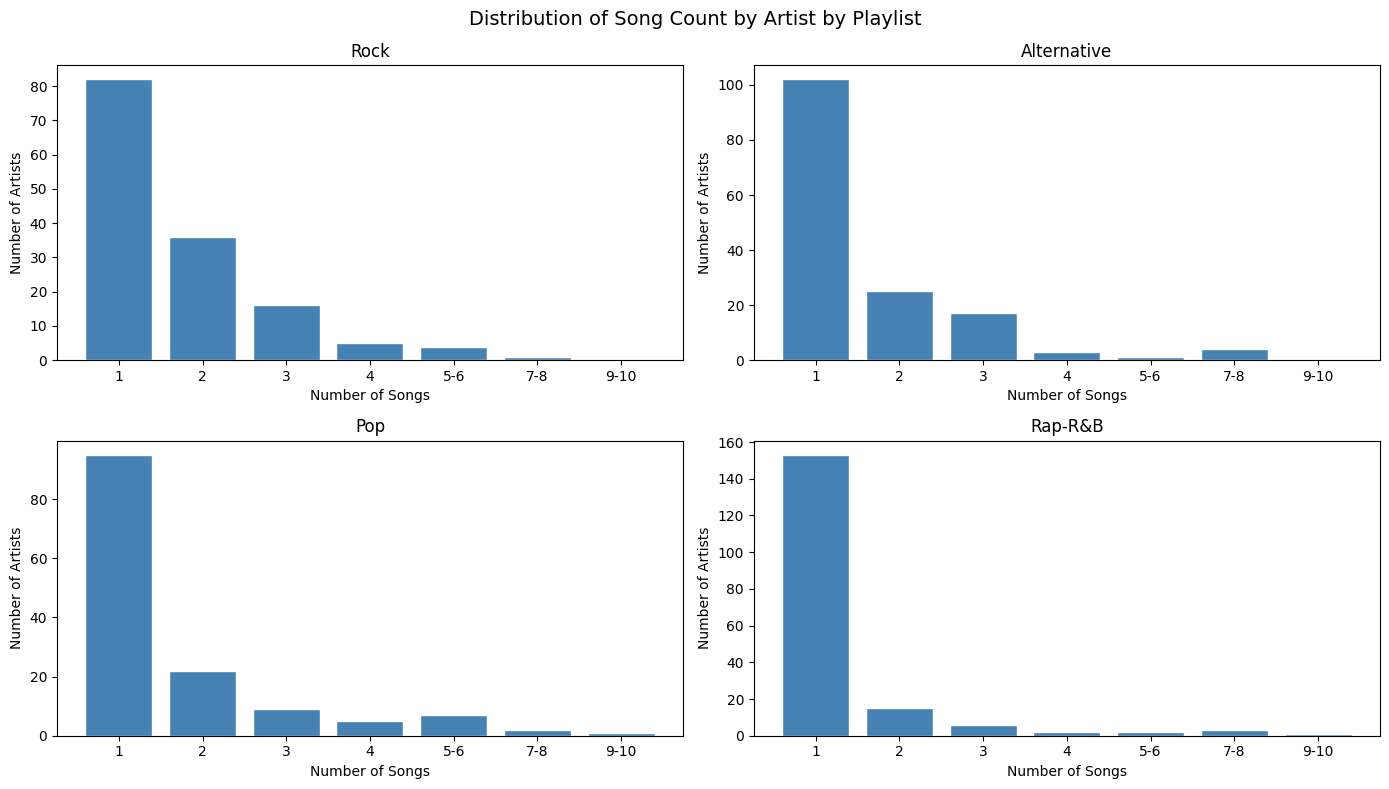

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

playlists = ['Rock', 'Alternative', 'Pop', 'Rap-R&B']

for ax, playlist in zip(axes, playlists):
    df_playlist = df_artists_by_playlist[df_artists_by_playlist['Playlist'] == playlist]
    df_playlist = df_playlist.copy()
    df_playlist['Bin'] = df_playlist['Count'].apply(bin_count)
    freq = df_playlist['Bin'].value_counts().reindex(bin_order, fill_value=0)
    ax.bar(freq.index, freq.values, color='steelblue', edgecolor='white')
    ax.set_xlabel('Number of Songs')
    ax.set_ylabel('Number of Artists')
    ax.set_title(f'{playlist}')

fig.suptitle('Distribution of Song Count by Artist by Playlist', fontsize=14)
plt.tight_layout()
plt.show()